# JADCO / Collection Équinoxe — Rent Economics

Cette phase explique la divergence contractuel/effectif à partir des sources internes, du starter et du moteur same-unit existant. Elle ne produit ni modèle 2026, ni prévision, ni backtest, ni formule de conversion finale. Les deux mesures originales sont conservées.

Les baux et concessions restent en mémoire. Aucune ligne individuelle, clé d’unité, adresse ou URL n’est affichée ou exportée. Les statistiques des groupes de moins de cinq observations sont masquées ; leurs effectifs restent visibles. Les catégories métier sources sont conservées telles quelles. Les montants sont exprimés en dollars ($), les ratios en pourcentages à l’affichage.

L’effectif des lignes détaillées n’est pas un nombre de concessions indépendantes prouvé. Les dates futures ne prouvent pas des coûts ou loyers réalisés futurs. Les résumés de concessions par année utilisent leur début, tandis que les analyses des baux utilisent `sLeaseFrom`.

In [1]:
from pathlib import Path
import sys
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
sys.path.insert(0, str(Path('..').resolve()))
from src.same_unit import UNIT_KEY, build_same_unit_pairs
from src.rent_economics import (calculate_gaps, attach_concessions, reconstruct_candidates,
                                error_metrics, CANDIDATES)
%matplotlib inline
plt.rcParams.update({'figure.figsize':(10,4),'axes.spines.top':False,'axes.spines.right':False})
pd.set_option('display.max_rows',100)
protected=list(Path('../data/raw').glob('*.csv'))+[Path(x) for x in
    ['starter.ipynb','01_data_audit.ipynb','02_eda_mix_effect.ipynb','03_same_unit_growth.ipynb','../src/same_unit.py']]
hashes={p:hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
id_types={c:'string' for c in ['sPropCode','sUnitCode','hUnit','hProperty','hBuilding']}
leases=pd.read_csv('../data/raw/equinoxe_lease_history.csv',dtype=id_types)
concessions=pd.read_csv('../data/raw/equinoxe_concessions.csv',dtype=id_types)
economics,links,join_report=attach_concessions(leases,concessions)
economics=reconstruct_candidates(economics)
economics['year']=economics._lease_start.dt.year
concessions['année concession']=pd.to_datetime(concessions.sDateFrom,format='mixed',errors='coerce').dt.year
LABELS={'baseline':'H0 : aucun ajustement','line_total':'H1 : lignes ponctuelles',
        'monthly_all':'H2 : lignes × durée enregistrée','promo_once':'H3 : PromoPay ponctuel, autres × durée',
        'indicator_monthly':'H4 : H2 conditionnée par sConcession'}

def metrics(df,groups=None):
    return error_metrics(df,groups).replace({'candidate':LABELS}).round(3)

def descriptive(df, groups, columns):
    rows=[]
    for key,part in df.groupby(groups,observed=True,dropna=False):
        key=key if isinstance(key,tuple) else (key,)
        for col in columns:
            x=pd.to_numeric(part[col],errors='coerce').replace([np.inf,-np.inf],np.nan).dropna()
            row=dict(zip(groups,key));row.update(variable=col,effectif=len(x))
            for label,value in [('moyenne',x.mean()),('médiane',x.median()),('Q25',x.quantile(.25)),('Q75',x.quantile(.75))]:
                row[label]=value if len(x)>=5 else np.nan
            rows.append(row)
    return pd.DataFrame(rows).round(3)

def note(s):display(Markdown('**Interprétation.** '+s))

## 1. Clés disponibles et stratégie de jointure

Les deux sources ont `sPropCode`, `sUnitCode`, `hUnit`, `hProperty` et `hBuilding`. La concession possède ses dates (`sDateFrom`, `sDateTo`) mais **aucun identifiant de bail ni sTermSeq**. `hUnit` identifie une unité, pas un bail.

La stratégie conserve `UNIT_KEY = (sPropCode, sUnitCode)` et recherche les baux dont l’intervalle inclusif contient `sDateFrom`. Une concession est associée seulement si **un unique bail** est candidat. Les handles `hUnit` et `hProperty` servent de vérification secondaire, sans remplacer la clé officielle. Les lignes non appariées ou ambiguës restent comptées ; aucune association au bail le plus proche n’est forcée.

On distingue association temporelle et reconstruction prudente. Pour cette dernière, toutes les lignes associées au bail doivent avoir des dates entièrement contenues dans celui-ci, des montants/durées exploitables, des handles cohérents et ne pas être des doublons exacts. Une concession commençant dans le bail mais finissant après est signalée ; on ne la découpe pas arbitrairement. Les baux restent présents, même sans reconstruction.

Les détails sont agrégés **avant** leur jointure aux baux ; `validate='one_to_one'` et les contrôles d’effectifs empêchent une multiplication accidentelle. Cette règle ne prouve pas que tous les détails économiques sont présents dans l’extrait.

In [2]:
report_labels={'concessions':'Lignes de concessions','leases':'Baux',
    'invalid_concession_key_or_dates':'Concessions à clé/date invalide','invalid_lease_key_or_dates':'Baux à clé/date invalide',
    'candidate_links':'Associations candidates','uniquely_assigned_concessions':'Concessions associées sans ambiguïté',
    'ambiguous_concessions':'Concessions ambiguës','unmatched_valid_concessions':'Concessions valides non appariées',
    'fully_contained_assigned_concessions':'Concessions associées entièrement contenues',
    'crossing_assigned_concessions':'Concessions dépassant la fin du bail',
    'handle_mismatch_links':'Associations à handles incohérents','leases_with_details':'Baux avec détails associés',
    'eligible_detail_leases':'Baux admissibles à la reconstruction prudente',
    'indicator_disagreement_leases':'Baux avec désaccord indicateur/détails'}
display(pd.Series({report_labels[k]:v for k,v in join_report.items()},name='Nombre').to_frame())
assert len(economics)==len(leases) and economics._lease_id.is_unique
print('Unités avec au moins une ligne détaillée :',len(concessions[list(UNIT_KEY)].drop_duplicates()))
display(pd.crosstab(economics.sConcession,economics.detail_count.gt(0)).rename(
    columns={False:'Sans détail associé',True:'Avec détail associé'}))
display(economics.detail_count.value_counts().sort_index().rename_axis('Nombre de lignes associées par bail').to_frame('Baux'))
unmatched=concessions.iloc[~np.isin(np.arange(len(concessions)),links._concession_id)]
display(unmatched.groupby('année concession').size().rename('Lignes non associées').to_frame())
display(links.groupby('sChargeCode').agg(lignes=('_concession_id','size'),
    dépassant_fin=('flag_crosses_lease_end','sum'),montant_médian=('sAmount','median'),durée_médiane=('sMonths','median')))
print('Écart nul sur tous les baux avec indicateur = 0 :',bool(economics.loc[economics.sConcession.eq(0),'contractual_effective_gap'].eq(0).all()))
note('Le désaccord sConcession/détails ne justifie pas de corriger automatiquement l’indicateur ni le loyer effectif. Il peut refléter des conventions de rattachement, des périodes différentes ou une couverture partielle ; ces explications restent à vérifier.')

,Nombre
Lignes de concessions,3560
Baux,4302
Concessions à clé/date invalide,0
Baux à clé/date invalide,0
Associations candidates,3356
Concessions associées sans ambiguïté,3356
Concessions ambiguës,0
Concessions valides non appariées,204
Concessions associées entièrement contenues,2641
Concessions dépassant la fin du bail,715


Unités avec au moins une ligne détaillée : 1014


detail_count,Sans détail associé,Avec détail associé
sConcession,,
0,1319,264
1,497,2222


,Baux
Nombre de lignes associées par bail,
0,1816
1,1771
2,574
3,127
4,14


,Lignes non associées
année concession,
2017,3
2018,4
2019,4
2020,12
2021,18
2022,21
2023,23
2024,51
2025,68


,lignes,dépassant_fin,montant_médian,durée_médiane
sChargeCode,,,,
Freeothe,519,193,-159.690,12.0
Indem,62,24,-144.335,12.0
PromoPay,1473,47,-1355.640,1.0
Referenc,33,10,-147.080,12.0
freeappl,36,15,-143.585,12.0
freelock,167,53,-141.810,12.0
freepark,915,321,-153.920,12.0
freerent,151,52,-137.970,12.0


Écart nul sur tous les baux avec indicateur = 0 : True


**Interprétation.** Le désaccord sConcession/détails ne justifie pas de corriger automatiquement l’indicateur ni le loyer effectif. Il peut refléter des conventions de rattachement, des périodes différentes ou une couverture partielle ; ces explications restent à vérifier.

## 2. Concessions : catégories, périodes et PromoPay

Le starter distingue notamment les rabais de loyer et avantages accessoires. Ici, les codes et leurs montants sont décrits sans les déclarer automatiquement mensuels. Le rapprochement de `sMonths` avec la durée des dates teste la cohérence de la période enregistrée, pas la périodicité des flux financiers.

PromoPay est étudié séparément : durée enregistrée, montant signé et rapport `−sAmount / sRent` du bail associé. Ce rapport mesure une taille relative de crédit, sans prétendre à une charge récurrente. Les données ne permettent pas à elles seules de décider si un montant est total, mensuel ou versé en plusieurs fois.

,sChargeCode,variable,effectif,moyenne,médiane,Q25,Q75
0,Freeothe,sAmount,570,-217.669,-153.485,-276.895,-68.850
1,Freeothe,sMonths,570,8.981,12.000,6.000,12.000
2,Indem,sAmount,69,-221.712,-149.260,-293.180,-50.190
3,Indem,sMonths,69,9.014,12.000,6.000,12.000
4,PromoPay,sAmount,1494,-1566.823,-1356.600,-2213.720,-761.610
5,PromoPay,sMonths,1494,1.118,1.000,1.000,1.000
6,Referenc,sAmount,36,-195.564,-148.255,-296.142,-84.960
7,Referenc,sMonths,36,9.778,12.000,6.000,12.000
8,freeappl,sAmount,44,-180.182,-143.585,-213.748,-80.035
9,freeappl,sMonths,44,9.682,12.000,6.000,12.000


,année concession,variable,effectif,moyenne,médiane,Q25,Q75
0,2017,sAmount,34,-309.245,-62.835,-137.840,-47.362
1,2017,sMonths,34,7.647,6.000,3.500,12.000
2,2018,sAmount,70,-295.866,-90.390,-347.648,-49.305
3,2018,sMonths,70,6.114,6.000,1.000,12.000
4,2019,sAmount,142,-397.504,-103.705,-523.710,-54.970
5,2019,sMonths,142,6.725,6.000,1.000,12.000
6,2020,sAmount,224,-402.196,-128.260,-588.690,-55.912
7,2020,sMonths,224,5.853,5.000,1.000,12.000
8,2021,sAmount,246,-466.241,-175.515,-754.950,-79.440
9,2021,sMonths,246,5.232,3.000,1.000,12.000


,sState,variable,effectif,moyenne,médiane,Q25,Q75
0,Ontario,sAmount,411,-1234.738,-472.64,-2094.15,-188.415
1,Ontario,sMonths,411,5.791,6.00,1.00,12.000
2,Quebec,sAmount,3149,-722.949,-293.82,-1105.27,-110.680
3,Quebec,sMonths,3149,5.692,3.00,1.00,12.000


,sPropCode,sBuilding,variable,effectif,moyenne,médiane,Q25,Q75
0,carlyle,Le Carlyle,sAmount,565,-871.596,-342.660,-1255.920,-144.340
1,carlyle,Le Carlyle,sMonths,565,5.929,6.000,1.000,12.000
2,dj1,Daniel-Johnson,sAmount,265,-868.916,-413.100,-1361.640,-153.800
3,dj1,Daniel-Johnson,sMonths,265,5.162,3.000,1.000,12.000
4,dj2,Daniel-Johnson,sAmount,212,-740.587,-323.750,-1121.250,-130.637
5,dj2,Daniel-Johnson,sMonths,212,5.755,3.000,1.000,12.000
6,levesque,Levesque,sAmount,472,-466.674,-178.120,-690.440,-65.590
7,levesque,Levesque,sMonths,472,5.837,5.500,1.000,12.000
8,metcalfe,The Met,sAmount,411,-1234.738,-472.640,-2094.150,-188.415
9,metcalfe,The Met,sMonths,411,5.791,6.000,1.000,12.000


,début_min,fin_max
sChargeCode,,
Freeothe,2017-01-01,2027-03-31
Indem,2018-05-01,2026-12-31
PromoPay,2017-08-01,2027-03-30
Referenc,2018-01-01,2026-10-31
freeappl,2018-09-01,2026-10-31
freelock,2017-07-01,2026-11-30
freepark,2017-01-01,2027-05-01
freerent,2017-07-01,2027-01-31


Différence médiane période inclusive en mois équivalents − sMonths : -0.014
PromoPay : lignes 1494 ; part sMonths = 1 (%) 88.22


,sMonths,variable,effectif,moyenne,médiane,Q25,Q75
0,1.0,sAmount,1318,-1682.829,-1476.24,-2339.808,-858.180
1,2.0,sAmount,176,-698.096,-588.99,-964.500,-266.818


,sMonths,variable,effectif,moyenne,médiane,Q25,Q75
0,1.0,montant relatif (%),1300,79.705,92.238,50.019,100.000
1,2.0,montant relatif (%),173,33.466,33.498,15.579,46.501


,year,sRenewal,variable,effectif,moyenne,médiane,Q25,Q75
0,2017,0,montant relatif (%),12,56.658,41.045,29.385,100.000
1,2017,1,montant relatif (%),1,NaN,NaN,NaN,NaN
2,2018,0,montant relatif (%),21,52.150,41.822,36.855,65.236
3,2018,1,montant relatif (%),8,51.791,46.244,9.653,100.000
4,2019,0,montant relatif (%),56,58.637,48.268,37.331,100.000
5,2019,1,montant relatif (%),29,47.387,45.005,21.870,52.583
6,2020,0,montant relatif (%),47,45.658,45.225,24.493,56.540
7,2020,1,montant relatif (%),47,54.331,50.220,30.690,100.000
8,2021,0,montant relatif (%),49,57.805,56.966,39.545,71.405
9,2021,1,montant relatif (%),79,60.859,59.778,34.750,100.000


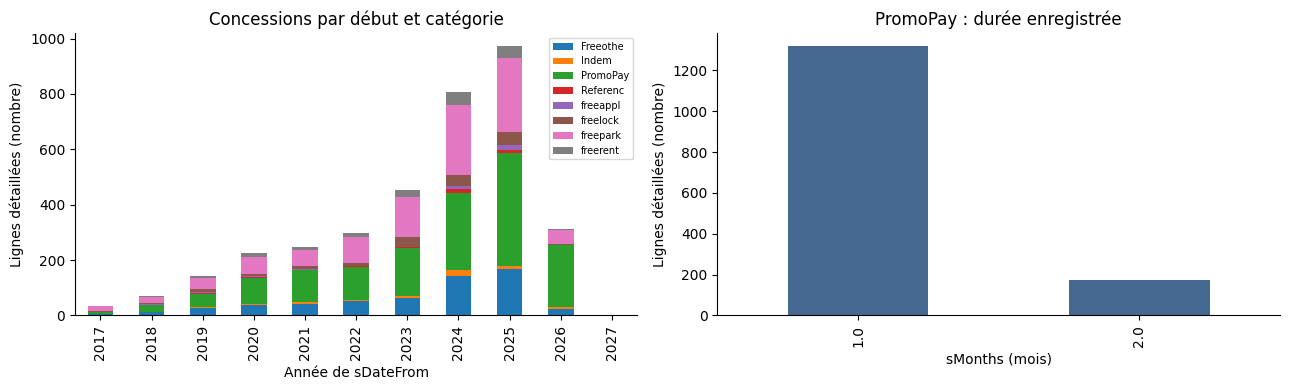

**Interprétation.** La concentration de PromoPay sur un ou deux mois est incompatible avec une lecture automatique de charge récurrente sur tout le bail. Le montant relatif et les erreurs de reconstruction sont nécessaires pour tester la sémantique ; aucun montant n’est multiplié aveuglément par la durée du bail.

In [3]:
for groups in [['sChargeCode'],['année concession'],['sState'],['sPropCode','sBuilding']]:
    display(descriptive(concessions,groups,['sAmount','sMonths']))
display(concessions.groupby('sChargeCode').agg(début_min=('sDateFrom','min'),fin_max=('sDateTo','max')))
concession_dates=(pd.to_datetime(concessions.sDateTo,format='mixed')-pd.to_datetime(concessions.sDateFrom,format='mixed')).dt.days
period_difference=(concession_dates+1)/(365.25/12)-concessions.sMonths
print('Différence médiane période inclusive en mois équivalents − sMonths :',round(period_difference.median(),3))
promo=concessions.loc[concessions.sChargeCode.eq('PromoPay')]
promo_links=links.loc[links.sChargeCode.eq('PromoPay')].merge(
    economics[['_lease_id','sRent','sRenewal','sState','year']],on='_lease_id',validate='many_to_one',suffixes=('','_bail'))
promo_links['montant relatif (%)']=-promo_links.sAmount/promo_links.sRent.where(promo_links.sRent.gt(0))*100
print('PromoPay : lignes',len(promo),'; part sMonths = 1 (%)',round(promo.sMonths.eq(1).mean()*100,2))
display(descriptive(promo,['sMonths'],['sAmount']))
display(descriptive(promo_links,['sMonths'],['montant relatif (%)']))
display(descriptive(promo_links,['year','sRenewal'],['montant relatif (%)']))
fig,axes=plt.subplots(1,2,figsize=(13,4))
pd.crosstab(concessions['année concession'],concessions.sChargeCode).plot.bar(stacked=True,ax=axes[0])
promo.groupby('sMonths').size().plot.bar(ax=axes[1],color='#456990')
axes[0].set(title='Concessions par début et catégorie',xlabel='Année de sDateFrom',ylabel='Lignes détaillées (nombre)')
axes[1].set(title='PromoPay : durée enregistrée',xlabel='sMonths (mois)',ylabel='Lignes détaillées (nombre)')
axes[0].legend(fontsize=7);plt.tight_layout();plt.show()
note('La concentration de PromoPay sur un ou deux mois est incompatible avec une lecture automatique de charge récurrente sur tout le bail. Le montant relatif et les erreurs de reconstruction sont nécessaires pour tester la sémantique ; aucun montant n’est multiplié aveuglément par la durée du bail.')

## 3. Hypothèses candidates de reconstruction

Toutes les hypothèses conservent le signe source des montants ; ici les crédits sont négatifs. Aucun coefficient n’est ajusté et aucun loyer négatif reconstruit n’est tronqué.

| Hypothèse | Formule | Interprétation à tester |
|---|---|---|
| H0 | `sRent` | Référence sans ajustement, pas conversion |
| H1 | `sRent + Σ(sAmount) / sTermMonths` | Chaque ligne représente un crédit total ponctuel |
| H2 | `sRent + Σ(sAmount × sMonths) / sTermMonths` | Montant par mois de la période enregistrée, puis amorti sur le bail |
| H3 | `sRent + Σ(sAmount × facteur) / sTermMonths`, facteur = 1 pour PromoPay, sinon sMonths | PromoPay ponctuel, autres lignes mensuelles |
| H4 | H2 si `sConcession = 1`, `sRent` si `sConcession = 0` | Tester le rôle de l’indicateur ; autre valeur indéterminée |

H4 est motivée par le constat interne que les baux avec indicateur nul ont un écart observé nul, même lorsque des lignes détaillées leur sont associées. Elle n’établit pas que ces lignes sont sans valeur économique.

H2 ne suppose **pas** que PromoPay s’applique chaque mois du bail : le facteur reste sa durée enregistrée, généralement un ou deux mois. La comparaison H2/H3 cible donc particulièrement les PromoPay à deux mois. H1/H2/H3/H4 restent des hypothèses de signification du champ, pas des faits comptables.

Les cinq hypothèses sont évaluées sur le **même périmètre prudent** de baux avec détails exploitables et terme strictement positif. H0 sur tous les baux est également fourni séparément. Les baux sans détail ne reçoivent pas un total de concession égal à zéro. L’erreur signée est `loyer reconstruit − sRentEffective` ; la MAE et la médiane absolue expriment la taille de l’erreur, le biais indique son sens.

Périmètre commun prudent : 1843 baux ; couverture (%) : 42.84


,candidate,effectif,MAE ($),erreur absolue médiane ($),biais moyen ($),Q05 erreur ($),Q95 erreur ($),part erreur ≤ 1 $ (%)
0,H0 : aucun ajustement,1843,161.752,139.080,161.752,48.703,339.170,0.434
1,H1 : lignes ponctuelles,1843,78.901,59.833,62.932,-64.552,239.153,24.634
2,H2 : lignes × durée enregistrée,1843,20.174,0.000,0.269,-74.867,79.284,73.304
3,"H3 : PromoPay ponctuel, autres × durée",1843,23.865,0.000,4.470,-72.687,97.894,67.336
4,H4 : H2 conditionnée par sConcession,1843,19.742,0.000,0.701,-70.896,79.284,73.738


,candidate,effectif,MAE ($),erreur absolue médiane ($),biais moyen ($),Q05 erreur ($),Q95 erreur ($),part erreur ≤ 1 $ (%)
0,H0 : aucun ajustement,4302,102.273,81.755,102.273,0.0,307.475,36.797


Périmètre élargi de sensibilité : 2486


,candidate,effectif,MAE ($),erreur absolue médiane ($),biais moyen ($),Q05 erreur ($),Q95 erreur ($),part erreur ≤ 1 $ (%)
0,H0 : aucun ajustement,2486,141.910,125.090,141.910,0.000,322.708,10.619
1,H1 : lignes ponctuelles,2486,72.032,51.669,51.814,-66.399,223.989,18.584
2,H2 : lignes × durée enregistrée,2486,49.847,0.001,-33.273,-212.397,66.951,54.344
3,"H3 : PromoPay ponctuel, autres × durée",2486,51.913,1.188,-29.343,-211.460,84.768,49.920
4,H4 : H2 conditionnée par sConcession,2486,35.564,0.000,-18.990,-172.095,66.951,64.964


H0 : aucun ajustement : reconstructions négatives (nombre) : 0
H1 : lignes ponctuelles : reconstructions négatives (nombre) : 0
H2 : lignes × durée enregistrée : reconstructions négatives (nombre) : 0
H3 : PromoPay ponctuel, autres × durée : reconstructions négatives (nombre) : 0
H4 : H2 conditionnée par sConcession : reconstructions négatives (nombre) : 0


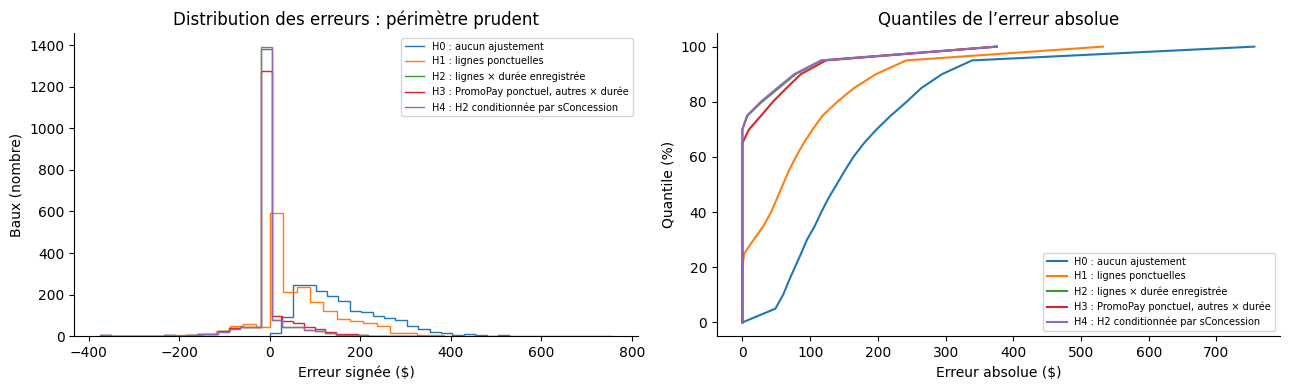

**Interprétation.** Une médiane d’erreur proche de zéro peut masquer des erreurs importantes sur une minorité. La comparaison des MAE, biais, queues et couverture empêche de conclure à une conversion universelle à partir d’une bonne médiane.

In [4]:
common=economics.loc[economics.eligible_details & economics.sTermMonths.gt(0)].copy()
common=common.loc[common[['error_'+h for h in CANDIDATES]].notna().all(axis=1)]
print('Périmètre commun prudent :',len(common),'baux ; couverture (%) :',round(len(common)/len(economics)*100,2))
display(metrics(common))
display(metrics(economics).iloc[:1])
# Sensibilité : même principe d'association, mais acceptation exploratoire des dépassements de fin.
broad=reconstruct_candidates(economics,prudent=False)
broad=broad.loc[broad[['error_'+h for h in CANDIDATES]].notna().all(axis=1)]
print('Périmètre élargi de sensibilité :',len(broad))
display(metrics(broad))
for h in CANDIDATES:
    print(LABELS[h],': reconstructions négatives (nombre) :',int(economics['flag_negative_reconstruction_'+h].sum()))
fig,axes=plt.subplots(1,2,figsize=(13,4))
for h in CANDIDATES:
    e=common['error_'+h].dropna().to_numpy()
    counts,edges=np.histogram(e,bins=30)
    axes[0].stairs(counts,edges,label=LABELS[h])
    sorted_abs=np.sort(np.abs(e))
    # Courbe issue de quantiles agrégés ; aucune erreur individuelle n'est encodée.
    qs=np.linspace(0,1,21)
    axes[1].plot(np.quantile(sorted_abs,qs),qs*100,label=LABELS[h])
axes[0].set(title='Distribution des erreurs : périmètre prudent',xlabel='Erreur signée ($)',ylabel='Baux (nombre)')
axes[1].set(title='Quantiles de l’erreur absolue',xlabel='Erreur absolue ($)',ylabel='Quantile (%)')
for ax in axes:ax.legend(fontsize=7)
plt.tight_layout();plt.show()
note('Une médiane d’erreur proche de zéro peut masquer des erreurs importantes sur une minorité. La comparaison des MAE, biais, queues et couverture empêche de conclure à une conversion universelle à partir d’une bonne médiane.')

## 4. Stabilité : années et segments

Les groupes utilisent les mêmes règles d’admissibilité. La combinaison exacte de codes associés est un segment descriptif ; elle ne prouve pas un ensemble exhaustif de concessions. Une concession isolée ne permet pas d’attribuer causalement l’écart à son type lorsque d’autres lignes sont présentes.

Le tableau par indicateur teste aussi les cas où des détails sont associés mais `sConcession = 0`. Les années regroupent les débuts de bail et ne représentent pas une date de versement ou de comptabilisation.

,year,candidate,effectif,MAE ($),erreur absolue médiane ($),biais moyen ($),Q05 erreur ($),Q95 erreur ($),part erreur ≤ 1 $ (%)
0,2017,H0 : aucun ajustement,35,53.182,54.120,53.182,31.031,70.732,0.000
1,2017,H1 : lignes ponctuelles,35,45.391,45.678,15.840,-105.166,60.841,14.286
2,2017,H2 : lignes × durée enregistrée,35,16.033,0.000,-13.518,-105.166,0.001,82.857
3,2017,"H3 : PromoPay ponctuel, autres × durée",35,16.033,0.000,-13.518,-105.166,0.001,82.857
4,2017,H4 : H2 conditionnée par sConcession,35,16.033,0.000,-13.518,-105.166,0.001,82.857
5,2018,H0 : aucun ajustement,56,55.469,55.695,55.469,27.063,84.087,0.000
6,2018,H1 : lignes ponctuelles,56,43.205,44.608,19.078,-95.439,60.850,16.071
7,2018,H2 : lignes × durée enregistrée,56,13.157,0.000,-12.901,-107.039,0.001,85.714
8,2018,"H3 : PromoPay ponctuel, autres × durée",56,13.971,0.000,-11.167,-97.287,10.041,78.571
9,2018,H4 : H2 conditionnée par sConcession,56,13.157,0.000,-12.901,-107.039,0.001,85.714


,sConcession,candidate,effectif,MAE ($),erreur absolue médiane ($),biais moyen ($),Q05 erreur ($),Q95 erreur ($),part erreur ≤ 1 $ (%)
0,0,H0 : aucun ajustement,8,0.000,0.000,0.000,0.000,0.000,100.000
1,0,H1 : lignes ponctuelles,8,99.350,94.086,-99.350,-146.729,-65.828,0.000
2,0,H2 : lignes × durée enregistrée,8,99.350,94.086,-99.350,-146.729,-65.828,0.000
3,0,"H3 : PromoPay ponctuel, autres × durée",8,99.350,94.086,-99.350,-146.729,-65.828,0.000
4,0,H4 : H2 conditionnée par sConcession,8,0.000,0.000,0.000,0.000,0.000,100.000
5,1,H0 : aucun ajustement,1835,162.457,139.530,162.457,49.749,339.253,0.000
6,1,H1 : lignes ponctuelles,1835,78.812,59.327,63.640,-58.998,239.539,24.741
7,1,H2 : lignes × durée enregistrée,1835,19.828,0.000,0.704,-71.234,79.329,73.624
8,1,"H3 : PromoPay ponctuel, autres × durée",1835,23.536,0.000,4.923,-70.044,98.066,67.629
9,1,H4 : H2 conditionnée par sConcession,1835,19.828,0.000,0.704,-71.234,79.329,73.624


,sRenewal,candidate,effectif,MAE ($),erreur absolue médiane ($),biais moyen ($),Q05 erreur ($),Q95 erreur ($),part erreur ≤ 1 $ (%)
0,0,H0 : aucun ajustement,1057,156.056,136.140,156.056,47.628,325.120,0.378
1,0,H1 : lignes ponctuelles,1057,77.046,57.642,63.085,-56.474,232.608,24.503
2,0,H2 : lignes × durée enregistrée,1057,17.114,0.000,-1.214,-71.206,59.209,77.010
3,0,"H3 : PromoPay ponctuel, autres × durée",1057,20.601,0.000,3.158,-69.997,87.003,70.672
4,0,H4 : H2 conditionnée par sConcession,1057,16.712,0.000,-0.811,-69.997,59.209,77.389
5,1,H0 : aucun ajustement,786,169.411,142.165,169.411,54.253,354.780,0.509
6,1,H1 : lignes ponctuelles,786,81.396,62.542,62.727,-68.687,243.300,24.809
7,1,H2 : lignes × durée enregistrée,786,24.287,0.000,2.264,-80.070,98.174,68.321
8,1,"H3 : PromoPay ponctuel, autres × durée",786,28.255,0.000,6.234,-80.070,111.153,62.850
9,1,H4 : H2 conditionnée par sConcession,786,23.817,0.000,2.734,-74.073,98.174,68.830


,sState,candidate,effectif,MAE ($),erreur absolue médiane ($),biais moyen ($),Q05 erreur ($),Q95 erreur ($),part erreur ≤ 1 $ (%)
0,Ontario,H0 : aucun ajustement,179,278.444,252.430,278.444,141.637,529.586,0.000
1,Ontario,H1 : lignes ponctuelles,179,120.417,111.525,105.630,-38.652,314.437,24.581
2,Ontario,H2 : lignes × durée enregistrée,179,33.250,0.000,6.572,-55.948,130.043,72.067
3,Ontario,"H3 : PromoPay ponctuel, autres × durée",179,38.995,0.000,13.267,-55.948,174.645,67.598
4,Ontario,H4 : H2 conditionnée par sConcession,179,33.250,0.000,6.572,-55.948,130.043,72.067
5,Quebec,H0 : aucun ajustement,1664,149.199,127.900,149.199,47.780,311.820,0.481
6,Quebec,H1 : lignes ponctuelles,1664,74.435,57.778,58.339,-66.324,227.966,24.639
7,Quebec,H2 : lignes × durée enregistrée,1664,18.767,0.000,-0.409,-77.602,72.404,73.438
8,Quebec,"H3 : PromoPay ponctuel, autres × durée",1664,22.237,0.000,3.524,-72.835,88.269,67.308
9,Quebec,H4 : H2 conditionnée par sConcession,1664,18.289,0.000,0.069,-71.773,72.404,73.918


,sTermMonths,candidate,effectif,MAE ($),erreur absolue médiane ($),biais moyen ($),Q05 erreur ($),Q95 erreur ($),part erreur ≤ 1 $ (%)
0,5.9,H0 : aucun ajustement,26,148.815,120.080,148.815,56.650,297.885,0.000
1,5.9,H1 : lignes ponctuelles,26,89.698,66.063,5.044,-235.124,146.561,15.385
2,5.9,H2 : lignes × durée enregistrée,26,55.326,0.003,-32.349,-244.399,81.693,53.846
3,5.9,"H3 : PromoPay ponctuel, autres × durée",26,57.841,0.808,-29.834,-244.399,81.889,50.000
4,5.9,H4 : H2 conditionnée par sConcession,26,55.326,0.003,-32.349,-244.399,81.693,53.846
5,12.0,H0 : aucun ajustement,1729,161.802,138.860,161.802,48.400,339.256,0.463
6,12.0,H1 : lignes ponctuelles,1729,78.746,59.897,63.129,-64.459,239.733,24.639
7,12.0,H2 : lignes × durée enregistrée,1729,19.980,0.000,0.499,-73.829,78.777,73.279
8,12.0,"H3 : PromoPay ponctuel, autres × durée",1729,23.796,0.000,4.732,-72.549,97.591,67.264
9,12.0,H4 : H2 conditionnée par sConcession,1729,19.520,0.000,0.959,-70.449,78.777,73.742


...

,year,variable,effectif,moyenne,médiane,Q25,Q75
0,2017,contractual_effective_gap,93,20.288,0.000,0.000,49.830
1,2017,relative_gap,93,0.012,0.000,0.000,0.028
2,2017,detail_count,93,0.452,0.000,0.000,1.000
3,2017,signed_monthly_total,37,-778.274,-640.560,-795.720,-558.480
4,2018,contractual_effective_gap,172,21.118,0.000,0.000,48.515
5,2018,relative_gap,172,0.014,0.000,0.000,0.034
6,2018,detail_count,172,0.529,0.000,0.000,1.000
7,2018,signed_monthly_total,69,-881.331,-717.630,-999.000,-536.760
8,2019,contractual_effective_gap,328,28.297,0.000,0.000,62.390
9,2019,relative_gap,328,0.017,0.000,0.000,0.038


,sRenewal,variable,effectif,moyenne,médiane,Q25,Q75
0,0,contractual_effective_gap,2337,97.863,76.000,0.00,160.160
1,0,relative_gap,2337,0.046,0.048,0.00,0.079
2,0,detail_count,2337,0.815,1.000,0.00,1.000
3,0,signed_monthly_total,1399,-2076.867,-1776.720,-2646.18,-1050.320
4,1,contractual_effective_gap,1965,107.518,89.060,0.00,168.020
5,1,relative_gap,1965,0.050,0.053,0.00,0.084
6,1,detail_count,1965,0.738,1.000,0.00,1.000
7,1,signed_monthly_total,1087,-2209.236,-1845.000,-2913.92,-1147.500


,sState,variable,effectif,moyenne,médiane,Q25,Q75
0,Ontario,contractual_effective_gap,352,233.734,226.125,154.427,315.272
1,Ontario,relative_gap,352,0.072,0.076,0.060,0.095
2,Ontario,detail_count,352,1.077,1.000,0.000,2.000
3,Ontario,signed_monthly_total,250,-3759.621,-3244.740,-4901.250,-2412.330
4,Quebec,contractual_effective_gap,3950,90.558,74.640,0.000,149.217
5,Quebec,relative_gap,3950,0.045,0.047,0.000,0.079
6,Quebec,detail_count,3950,0.754,1.000,0.000,1.000
7,Quebec,signed_monthly_total,2236,-1953.073,-1676.280,-2551.380,-1033.830


,sTermMonths,variable,effectif,moyenne,médiane,Q25,Q75
0,5.9,contractual_effective_gap,76,103.039,82.620,0.00,157.365
1,5.9,relative_gap,76,0.044,0.051,0.00,0.073
2,5.9,detail_count,76,0.645,0.000,0.00,1.000
3,5.9,signed_monthly_total,37,-1491.390,-959.150,-2100.00,-451.080
4,12.0,contractual_effective_gap,4067,101.936,81.480,0.00,162.915
5,12.0,relative_gap,4067,0.047,0.051,0.00,0.081
6,12.0,detail_count,4067,0.777,1.000,0.00,1.000
7,12.0,signed_monthly_total,2341,-2099.038,-1795.440,-2688.48,-1092.600
8,17.9,contractual_effective_gap,93,108.837,80.190,0.00,180.810
9,17.9,relative_gap,93,0.049,0.054,0.00,0.083


,concession_types,variable,effectif,moyenne,médiane,Q25,Q75
0,Aucun détail associé,contractual_effective_gap,1816,48.013,0.000,0.000,64.053
1,Aucun détail associé,relative_gap,1816,0.022,0.000,0.000,0.042
2,Aucun détail associé,detail_count,1816,0.000,0.000,0.000,0.000
3,Aucun détail associé,signed_monthly_total,0,NaN,NaN,NaN,NaN
4,Freeothe,contractual_effective_gap,270,120.530,111.860,49.927,175.488
...,...,...,...,...,...,...,...
219,freepark + freerent,signed_monthly_total,11,-1790.343,-1169.250,-2778.465,-849.915
220,freerent,contractual_effective_gap,67,121.864,106.650,54.310,180.660
221,freerent,relative_gap,67,0.058,0.063,0.039,0.084
222,freerent,detail_count,67,1.000,1.000,1.000,1.000


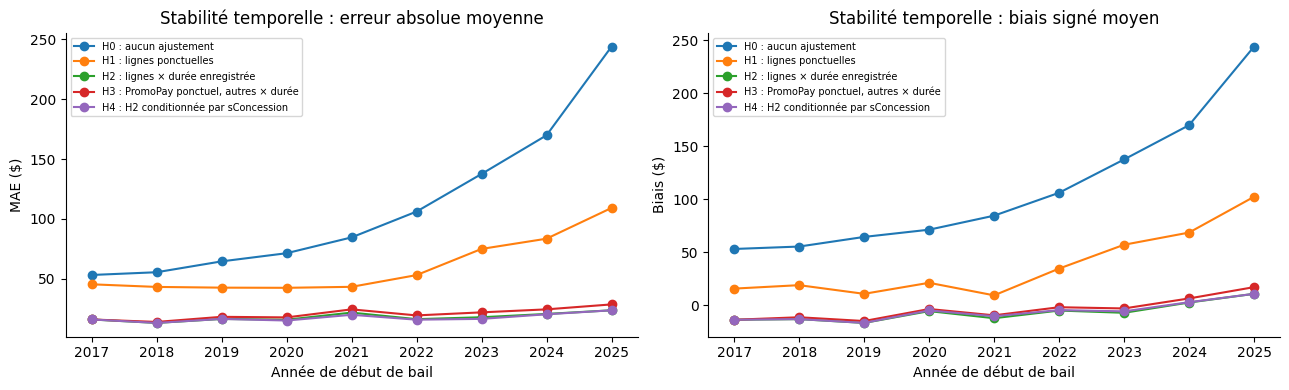

**Interprétation.** Les erreurs changent selon les périodes, les catégories et la qualité du rattachement. Le périmètre prudent est une sélection de baux avec détails contenus ; sa performance ne doit pas être extrapolée aux autres baux ou à une année future.

In [5]:
for groups in [['year'],['sConcession'],['sRenewal'],['sState'],['sTermMonths'],
               ['sPropCode','sBuilding'],['concession_types']]:
    display(metrics(common,groups))
# Comparaison contrôlée du traitement PromoPay sur les baux ayant un PromoPay associé.
promo_ids=links.loc[links.sChargeCode.eq('PromoPay'),'_lease_id'].unique()
common_promo=common.loc[common._lease_id.isin(promo_ids)]
display(metrics(common_promo))
# Rapports économiques agrégés par catégories de combinaisons.
for groups in [['year'],['sRenewal'],['sState'],['sTermMonths'],['concession_types']]:
    display(descriptive(economics,groups,['contractual_effective_gap','relative_gap','detail_count','signed_monthly_total']))
fig,axes=plt.subplots(1,2,figsize=(13,4))
annual_errors=error_metrics(common,['year'])
for h in CANDIDATES:
    part=annual_errors.loc[annual_errors.candidate.eq(h)]
    axes[0].plot(part.year,part['MAE ($)'],marker='o',label=LABELS[h])
    axes[1].plot(part.year,part['biais moyen ($)'],marker='o',label=LABELS[h])
axes[0].set(title='Stabilité temporelle : erreur absolue moyenne',xlabel='Année de début de bail',ylabel='MAE ($)')
axes[1].set(title='Stabilité temporelle : biais signé moyen',xlabel='Année de début de bail',ylabel='Biais ($)')
for ax in axes:ax.legend(fontsize=7)
plt.tight_layout();plt.show()
note('Les erreurs changent selon les périodes, les catégories et la qualité du rattachement. Le périmètre prudent est une sélection de baux avec détails contenus ; sa performance ne doit pas être extrapolée aux autres baux ou à une année future.')

## 5. Lien avec les transitions Same-Unit

On réutilise le moteur existant, sans changer ses calculs ni ses 3 241 transitions. Les diagnostics économiques sont rattachés séparément au bail ancien et nouveau par **UNIT_KEY + date de début**, avec validation plusieurs-vers-un. Si cette clé de bail était ambiguë, la jointure échouerait plutôt que multiplier les paires.

Une identité utile relie les deux croissances et les écarts relatifs observés `q` :

`1 + effective_growth = (1 + contractual_growth) × (1 − q_new) / (1 − q_old)`.

Cette identité est une conséquence algébrique des loyers observés, **pas une prédiction ni une conversion indépendante**. Elle explique mathématiquement comment l’évolution de l’écart relatif peut modifier la croissance effective. Elle ne prouve pas que les lignes détaillées sont la cause de tout l’écart.

Identité algébrique vérifiée sur 3241 transitions.


,year,sRenewal,variable,effectif,moyenne,médiane,Q25,Q75
0,2017,0,contractual_growth_pct,1,NaN,NaN,NaN,NaN
1,2017,0,effective_growth_pct,1,NaN,NaN,NaN,NaN
2,2017,0,growth_difference_pp,1,NaN,NaN,NaN,NaN
3,2017,0,gap_change_pp,1,NaN,NaN,NaN,NaN
4,2017,0,new_gap_pct,1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
121,2025,1,growth_difference_pp,483,4.113,3.447,2.589,4.993
122,2025,1,gap_change_pp,483,3.745,2.968,2.242,4.328
123,2025,1,new_gap_pct,483,9.452,10.434,9.157,11.567
124,2025,1,new_detail_count,483,0.791,1.000,0.000,1.000


,year,sState,variable,effectif,moyenne,médiane,Q25,Q75
0,2017,Quebec,contractual_growth_pct,3,NaN,NaN,NaN,NaN
1,2017,Quebec,effective_growth_pct,3,NaN,NaN,NaN,NaN
2,2017,Quebec,growth_difference_pp,3,NaN,NaN,NaN,NaN
3,2017,Quebec,gap_change_pp,3,NaN,NaN,NaN,NaN
4,2017,Quebec,new_gap_pct,3,NaN,NaN,NaN,NaN
5,2017,Quebec,new_detail_count,3,NaN,NaN,NaN,NaN
6,2017,Quebec,new_signed_monthly_total,1,NaN,NaN,NaN,NaN
7,2018,Quebec,contractual_growth_pct,93,2.285,2.655,1.015,3.774
8,2018,Quebec,effective_growth_pct,93,2.105,2.172,0.369,4.042
9,2018,Quebec,growth_difference_pp,93,0.179,0.000,0.000,0.711


,sState,sRenewal,variable,effectif,moyenne,médiane,Q25,Q75
0,Ontario,0,contractual_growth_pct,97,7.468,7.892,5.405,9.921
1,Ontario,0,effective_growth_pct,97,4.696,4.849,1.666,7.227
2,Ontario,0,growth_difference_pp,97,2.772,2.919,1.297,4.162
3,Ontario,0,gap_change_pp,97,2.470,2.502,1.188,3.583
4,Ontario,0,new_gap_pct,97,8.249,8.876,6.967,10.657
5,Ontario,0,new_detail_count,97,0.918,1.000,0.000,1.000
6,Ontario,0,new_signed_monthly_total,61,-4062.918,-3546.720,-5289.530,-2697.960
7,Ontario,1,contractual_growth_pct,131,4.631,4.396,2.981,6.293
8,Ontario,1,effective_growth_pct,131,1.133,1.920,0.342,3.390
9,Ontario,1,growth_difference_pp,131,3.498,2.949,1.331,4.883


,sBuilding,variable,effectif,moyenne,médiane,Q25,Q75
0,Daniel-Johnson,contractual_growth_pct,548,4.615,4.206,2.800,6.409
1,Daniel-Johnson,effective_growth_pct,548,3.146,3.031,-0.614,6.400
2,Daniel-Johnson,growth_difference_pp,548,1.469,0.814,0.000,4.899
3,Daniel-Johnson,gap_change_pp,548,1.415,0.735,0.000,4.431
4,Daniel-Johnson,new_gap_pct,548,4.636,5.280,0.000,8.293
5,Daniel-Johnson,new_detail_count,548,0.668,1.000,0.000,1.000
6,Daniel-Johnson,new_signed_monthly_total,285,-2225.604,-1836.120,-2751.020,-1272.600
7,Le Carlyle,contractual_growth_pct,343,5.768,5.752,3.633,7.514
8,Le Carlyle,effective_growth_pct,343,2.686,2.844,0.040,5.236
9,Le Carlyle,growth_difference_pp,343,3.082,2.884,1.262,4.692


,new_sConcession,variable,effectif,moyenne,médiane,Q25,Q75
0,0,contractual_growth_pct,1176,3.875,3.733,2.073,5.639
1,0,effective_growth_pct,1176,6.852,6.171,3.266,9.863
2,0,growth_difference_pp,1176,-2.977,0.000,-5.744,0.000
3,0,gap_change_pp,1176,-2.685,0.000,-5.253,0.000
4,0,new_gap_pct,1176,0.000,0.000,0.000,0.000
5,0,new_detail_count,1176,0.204,0.000,0.000,0.000
6,0,new_signed_monthly_total,219,-1615.485,-1388.760,-2164.500,-897.000
7,1,contractual_growth_pct,2065,5.030,4.814,2.894,6.883
8,1,effective_growth_pct,2065,0.973,1.482,-1.935,3.796
9,1,growth_difference_pp,2065,4.058,3.438,1.247,5.897


,new_concession_types,variable,effectif,moyenne,médiane,Q25,Q75
0,Aucun détail associé,contractual_growth_pct,1442,4.352,4.106,2.383,6.171
1,Aucun détail associé,effective_growth_pct,1442,4.934,4.302,1.729,8.407
2,Aucun détail associé,growth_difference_pp,1442,-0.581,0.000,-4.447,1.512
3,Aucun détail associé,gap_change_pp,1442,-0.484,0.000,-4.031,1.359
4,Aucun détail associé,new_gap_pct,1442,2.667,0.000,0.000,5.948
...,...,...,...,...,...,...,...
324,freerent,growth_difference_pp,49,1.570,1.348,0.000,4.201
325,freerent,gap_change_pp,49,1.459,1.195,0.000,3.548
326,freerent,new_gap_pct,49,5.668,6.099,0.000,8.439
327,freerent,new_detail_count,49,1.000,1.000,1.000,1.000


,new_sTermMonths,variable,effectif,moyenne,médiane,Q25,Q75
0,5.9,contractual_growth_pct,57,2.021,1.961,0.962,3.182
1,5.9,effective_growth_pct,57,0.662,0.911,-1.188,2.439
2,5.9,growth_difference_pp,57,1.359,0.917,0.000,3.971
3,5.9,gap_change_pp,57,1.338,0.827,0.000,3.509
4,5.9,new_gap_pct,57,4.923,5.625,0.000,7.795
5,5.9,new_detail_count,57,0.579,0.000,0.000,1.000
6,5.9,new_signed_monthly_total,25,-1672.176,-968.880,-2100.000,-518.370
7,12.0,contractual_growth_pct,3072,4.543,4.340,2.611,6.418
8,12.0,effective_growth_pct,3072,3.043,2.947,-0.086,5.882
9,12.0,growth_difference_pp,3072,1.499,1.075,0.000,4.183


paires  part_indicateur  part_détails  part_détails_prudents  \
year sRenewal                                                                 
2017 0              1            0.000         0.000                  0.000   
     1              2           50.000        50.000                 50.000   
2018 0             42           30.952        35.714                 28.571   
     1             51           43.137        41.176                 33.333   
2019 0             69           43.478        46.377                 27.536   
     1             97           48.454        45.361                 36.082   
2020 0            133           48.872        45.865                 33.835   
     1            201           47.761        45.274                 29.353   
2021 0            136           54.412        52.941                 34.559   
     1            225           53.778        52.444                 34.667   
2022 0            127           55.118        57.480                 34.646   
     1            232           59.914        53.017                 36.207   
2023 0            178           50.000        57.303                 30.337   
     1            246           47.561        50.813                 25.203   
2024 0            278           71.942        58.633                 34.532   
     1            428           68.458        59.112                 32.477   
2025 0            312           83.333        62.179                 61.859   
     1            483           88.613        64.389                 64.389   

               terme_médian  
year sRenewal                
2017 0                 12.0  
     1                 12.0  
2018 0                 12.0  
     1                 12.0  
2019 0                 12.0  
     1                 12.0  
2020 0                 12.0  
     1                 12.0  
2021 0                 12.0  
     1                 12.0  
2022 0                 12.0  
     1                 12.0  
2023 0                 12.0  
     1                 12.0  
2024 0                 12.0  
     1                 12.0  
2025 0                 12.0  
     1                 12.0

,variable,mesure,effectif,Pearson
0,new_sTermMonths,contractual_growth,3241,0.224
1,new_sTermMonths,effective_growth,3241,0.126
2,new_sTermMonths,growth_difference_pp,3241,0.010
3,new_sConcession,contractual_growth,3241,0.176
4,new_sConcession,effective_growth,3241,-0.541
5,new_sConcession,growth_difference_pp,3241,0.713
6,new_detail_count,contractual_growth,3241,0.040
7,new_detail_count,effective_growth,3241,-0.293
8,new_detail_count,growth_difference_pp,3241,0.349
9,new_signed_line_total,contractual_growth,1799,-0.248


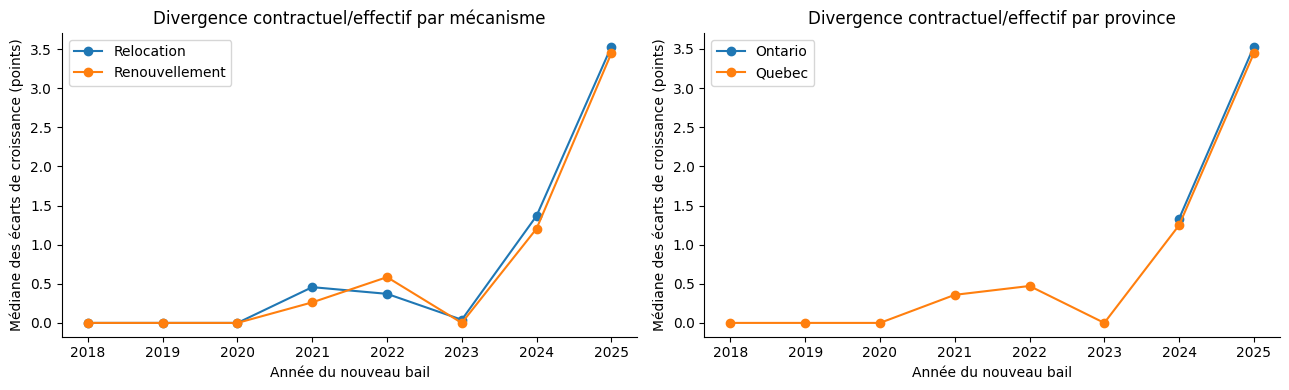

**Interprétation.** La différence entre deux médianes de croissance n’est pas la médiane des différences individuelles. Les corrélations avec gap_change_pp reflètent en partie l’identité algébrique ; elles ne constituent pas une preuve causale. Les montants associés sont partiels et non annualisés comme coûts comptables.

In [6]:
pairs,trace=build_same_unit_pairs(leases)
fields=['contractual_effective_gap','relative_gap','detail_count','signed_line_total','signed_monthly_total',
        'eligible_details','concession_types','flag_indicator_disagreement']
lookup=economics[list(UNIT_KEY)+['_lease_start']+fields]
assert not lookup.duplicated(list(UNIT_KEY)+['_lease_start']).any()
for side in ['old','new']:
    renamed=lookup.rename(columns={'_lease_start':side+'_lease_date',**{col:side+'_'+col for col in fields}})
    pairs=pairs.merge(renamed,on=list(UNIT_KEY)+[side+'_lease_date'],how='left',validate='many_to_one')
assert len(pairs)==trace['constructed_pairs']==3241
pairs['growth_difference_pp']=(pairs.contractual_growth-pairs.effective_growth)*100
pairs['gap_change_pp']=(pairs.new_relative_gap-pairs.old_relative_gap)*100
pairs['new_gap_pct']=pairs.new_relative_gap*100
pairs['new_detail_present']=pairs.new_detail_count.gt(0).astype(int)
pairs['detail_presence_change']=pairs.new_detail_count.gt(0).astype(int)-pairs.old_detail_count.gt(0).astype(int)
identity=(1+pairs.contractual_growth)*(1-pairs.new_relative_gap)/(1-pairs.old_relative_gap)-1
valid=identity.notna() & pairs.effective_growth.notna()
assert np.allclose(identity[valid],pairs.loc[valid,'effective_growth'])
print('Identité algébrique vérifiée sur',int(valid.sum()),'transitions.')
pairs['contractual_growth_pct']=pairs.contractual_growth*100
pairs['effective_growth_pct']=pairs.effective_growth*100
for groups in [['year','sRenewal'],['year','sState'],['sState','sRenewal'],['sBuilding'],
               ['new_sConcession'],['new_concession_types'],['new_sTermMonths']]:
    display(descriptive(pairs,groups,['contractual_growth_pct','effective_growth_pct','growth_difference_pp',
        'gap_change_pp','new_gap_pct','new_detail_count','new_signed_monthly_total']))
# Fréquences calculées sur toutes les transitions, montants seulement lorsqu'associés.
transition_summary=pairs.groupby(['year','sRenewal']).agg(paires=('year','size'),
    part_indicateur=('new_sConcession',lambda x:x.eq(1).mean()*100),
    part_détails=('new_detail_present',lambda x:x.mean()*100),
    part_détails_prudents=('new_eligible_details',lambda x:x.mean()*100),
    terme_médian=('new_sTermMonths','median'))
display(transition_summary.round(3))
associations=[]
for feature in ['new_sTermMonths','new_sConcession','new_detail_count','new_signed_line_total',
                'new_signed_monthly_total','gap_change_pp']:
    for target in ['contractual_growth','effective_growth','growth_difference_pp']:
        d=pairs[[feature,target]].apply(pd.to_numeric,errors='coerce').dropna()
        associations.append({'variable':feature,'mesure':target,'effectif':len(d),
                             'Pearson':d[feature].corr(d[target]) if len(d)>=5 else np.nan})
display(pd.DataFrame(associations).round(3))
fig,axes=plt.subplots(1,2,figsize=(13,4))
for grouping,ax in [('sRenewal',axes[0]),('sState',axes[1])]:
    for value,part in pairs.groupby(grouping):
        grouped=part.groupby('year')['growth_difference_pp']
        med=grouped.median().where(grouped.count().ge(5))
        label={0:'Relocation',1:'Renouvellement'}.get(value,str(value))
        ax.plot(med.index,med,marker='o',label=label)
    ax.set(xlabel='Année du nouveau bail',ylabel='Médiane des écarts de croissance (points)')
    ax.legend()
axes[0].set_title('Divergence contractuel/effectif par mécanisme')
axes[1].set_title('Divergence contractuel/effectif par province')
plt.tight_layout();plt.show()
note('La différence entre deux médianes de croissance n’est pas la médiane des différences individuelles. Les corrélations avec gap_change_pp reflètent en partie l’identité algébrique ; elles ne constituent pas une preuve causale. Les montants associés sont partiels et non annualisés comme coûts comptables.')

## 6. Évaluation des définitions candidates du loyer

| Critère | Option A : contractuel | Option B : effectif fourni | Option C : combinée / normalisée |
|---|---|---|---|
| Interprétation métier | Prix inscrit au bail | Niveau net selon la convention source ; plus proche de l’économie des avantages | Dépend de conventions de crédit/période encore incomplètement établies |
| Stabilité historique | Champ disponible, mais hausse ne reflétant pas toute l’évolution des avantages | Écart contractuel/effectif variable ; information économique à conserver | Résidus variables selon année, segment et rattachement |
| Sensibilité aux concessions | Les ignore dans le niveau contractuel | Les incorpore selon une règle source non entièrement vérifiée | Dépend du détail et du traitement choisi |
| Comparabilité same-unit | Toutes les paires calculables | Toutes les paires calculables ; concessions comparées entre ancien et nouveau | Couverture réduite ; risque de changer de mesure selon le bail |
| Qualité des données | Pas de reconstruction nécessaire | Directement fourni, mais conventions à confirmer | Détails non exhaustifs ou dépassant le bail et désaccords d’indicateur |
| Backtest futur | Faisable avec dates et fenêtres documentées | Faisable avec convention constante et disponibilité à la date de coupure | Nécessiterait d’abord des règles fiables d’association et disponibilité temporelle |
| Risque | Présenter la croissance contractuelle comme croissance économique nette | Présenter un champ calculé comme encaissement audité | Fausse précision et conversion universelle injustifiée |

**Recommandation provisoire : option B pour mesurer l’économie nette du loyer, confiance modérée**, en conservant A comme mesure complémentaire obligatoire. L’option B utilise le champ fourni, sans le remplacer par une approximation. Sa signification exacte et sa construction doivent encore être confirmées ; il ne s’agit pas d’une preuve d’encaissements réalisés. Si la question finale porte sur le prix contractuel, A peut devenir la mesure principale.

**Option C non retenue à ce stade** : une formule peut reproduire une grande partie des baux prudents mais échoue ailleurs et sa couverture est partielle. Les analyses ne justifient ni moyenne arbitraire des deux loyers ni remplacement de sRentEffective. La recommandation restera révisable après clarification métier, données externes et validation historique ultérieure ; aucun de ces travaux n’est commencé ici.

## 7. Vérification d’intégrité

In [7]:
assert all(hashlib.sha256(p.read_bytes()).hexdigest()==digest for p,digest in hashes.items())
assert len(economics)==len(leases) and economics._lease_id.is_unique
assert len(pairs)==3241
print('CSV, starter, audit, EDA et moteur Same-Unit inchangés. Aucun export individuel ni CSV créé.')

CSV, starter, audit, EDA et moteur Same-Unit inchangés. Aucun export individuel ni CSV créé.


La cellule suivante régénère les constats à partir des seuls agrégats.

In [8]:
overall_metrics=error_metrics(common).set_index('candidate')
annual_metrics=error_metrics(common,['year'])
sections={
'FAITS CONFIRMÉS':[f"{len(economics)} baux et {len(concessions)} lignes détaillées ; {join_report['uniquely_assigned_concessions']} lignes associées à un unique bail, {join_report['unmatched_valid_concessions']} non appariées, {join_report['ambiguous_concessions']} ambiguës. {len(pairs)} transitions same-unit conservées."],
'CONCESSIONS':[f"{join_report['crossing_assigned_concessions']} lignes associées dépassent la fin de leur bail ; {join_report['eligible_detail_leases']} baux admissibles à la reconstruction prudente ({len(common)/len(economics)*100:.2f} % du total). {join_report['indicator_disagreement_leases']} baux présentent un désaccord entre sConcession et présence de détails associés.",
'Les montants sont des crédits signés ; aucune absence de détail n’est remplacée par un crédit nul. Les avantages accessoires restent identifiables par code.'],
'PROMOPAY':[f"{len(promo)} lignes ; {promo.sMonths.eq(1).mean()*100:.2f} % avec sMonths = 1 et {(promo.sMonths.eq(2)).mean()*100:.2f} % avec sMonths = 2. Le rapport médian −sAmount/sRent vaut {promo_links['montant relatif (%)'].median():.2f} % sur les lignes associées. Le code n’est pas traité comme charge mensuelle sur tout le bail."],
'CONTRACTUAL VS EFFECTIVE':[
'Les écarts sont économiquement substantiels et variables. L’identité entre changements d’écart relatif et divergence des croissances est vérifiée, mais ne détermine pas la cause comptable de chaque écart.'],
'RENEWAL VS RELOCATION':[], 'QUÉBEC VS ONTARIO':[],
'HYPOTHÈSES DE NORMALISATION TESTÉES':[],
'MEILLEURE DÉFINITION CANDIDATE DU LOYER':['B provisoirement pour une mesure économique nette, confiance modérée ; A conservée comme mesure contractuelle complémentaire. C non justifiée comme conversion universelle.'],
'INCERTITUDES RESTANTES':['Absence d’identifiant de bail dans les concessions, couverture partielle, périodes dépassant les baux et indicateurs divergents : la règle source de sRentEffective n’est pas entièrement reconstruite.',
'Les bonnes performances sur le périmètre prudent ne démontrent ni stabilité générale ni validité hors période. Les conventions mensuel/ponctuel restent des hypothèses par catégorie.'],
'IMPLICATIONS POUR LE FORECAST 2026':['Conserver les deux mesures et les segments renouvellement/relocation, bâtiment et province ; garder The Met/ Ontario distinct, sans inférer de réglementation.',
'Documenter la disponibilité à date des concessions et les conventions de périodes avant un backtest futur. Aucune pondération finale, conversion irréversible ou prévision 2026 n’est construite.']}
for h,row in overall_metrics.iterrows():
    sections['HYPOTHÈSES DE NORMALISATION TESTÉES'].append(f"{LABELS[h]} — {int(row['effectif'])} baux prudents : MAE {row['MAE ($)']:.3f} $, erreur absolue médiane {row['erreur absolue médiane ($)']:.3f} $, biais {row['biais moyen ($)']:.3f} $, {row['part erreur ≤ 1 $ (%)']:.2f} % à ±1 $.")
h2=annual_metrics.loc[annual_metrics.candidate.eq('monthly_all')]
sections['HYPOTHÈSES DE NORMALISATION TESTÉES'].append(f"H2 : MAE annuelle entre {h2['MAE ($)'].min():.3f} et {h2['MAE ($)'].max():.3f} $ ; biais de {h2.loc[h2.year.eq(2017),'biais moyen ($)'].iloc[0]:.3f} $ en 2017 à {h2.loc[h2.year.eq(2025),'biais moyen ($)'].iloc[0]:.3f} $ en 2025. La stabilité complète n’est pas démontrée.")
sections['CONTRACTUAL VS EFFECTIVE'].append(f"Les {int(economics.sConcession.eq(0).sum())} baux avec sConcession = 0 ont un écart contractuel/effectif nul. Parmi eux, {int((economics.sConcession.eq(0) & economics.detail_count.gt(0)).sum())} ont cependant des détails associés ; la présence de lignes seule ne suffit donc pas à reconstruire le champ.")
for types in ['Freeothe + freepark','PromoPay']:
    category_metrics=error_metrics(common.loc[common.concession_types.eq(types)]).set_index('candidate')
    row=category_metrics.loc['monthly_all']
    sections['HYPOTHÈSES DE NORMALISATION TESTÉES'].append(f"H2 — {types} : {int(row['effectif'])} baux, MAE {row['MAE ($)']:.3f} $, {row['part erreur ≤ 1 $ (%)']:.2f} % à ±1 $. La qualité diffère fortement selon la combinaison observée.")
for group,title in [('sRenewal','RENEWAL VS RELOCATION'),('sState','QUÉBEC VS ONTARIO')]:
    for value,part in pairs.loc[pairs.year.eq(2025)].groupby(group):
        label={0:'Relocation',1:'Renouvellement'}.get(value,str(value))
        sections[title].append(f"2025 — {label} : {len(part)} transitions ; médianes brutes contractuelle {part.contractual_growth.median()*100:.3f} %, effective {part.effective_growth.median()*100:.3f} %, écart relatif nouveau moyen {part.new_gap_pct.mean():.3f} % ; {part.new_sConcession.eq(1).mean()*100:.2f} % de nouveaux baux avec indicateur de concession.")
conclusion='## Constats Rent Economics\n\n'+'\n\n'.join('### '+title+'\n\n'+'\n'.join('- '+text for text in texts) for title,texts in sections.items())
display(Markdown(conclusion))

## Constats Rent Economics

### FAITS CONFIRMÉS

- 4302 baux et 3560 lignes détaillées ; 3356 lignes associées à un unique bail, 204 non appariées, 0 ambiguës. 3241 transitions same-unit conservées.

### CONCESSIONS

- 715 lignes associées dépassent la fin de leur bail ; 1843 baux admissibles à la reconstruction prudente (42.84 % du total). 761 baux présentent un désaccord entre sConcession et présence de détails associés.
- Les montants sont des crédits signés ; aucune absence de détail n’est remplacée par un crédit nul. Les avantages accessoires restent identifiables par code.

### PROMOPAY

- 1494 lignes ; 88.22 % avec sMonths = 1 et 11.78 % avec sMonths = 2. Le rapport médian −sAmount/sRent vaut 80.13 % sur les lignes associées. Le code n’est pas traité comme charge mensuelle sur tout le bail.

### CONTRACTUAL VS EFFECTIVE

- Les écarts sont économiquement substantiels et variables. L’identité entre changements d’écart relatif et divergence des croissances est vérifiée, mais ne détermine pas la cause comptable de chaque écart.
- Les 1583 baux avec sConcession = 0 ont un écart contractuel/effectif nul. Parmi eux, 264 ont cependant des détails associés ; la présence de lignes seule ne suffit donc pas à reconstruire le champ.

### RENEWAL VS RELOCATION

- 2025 — Relocation : 312 transitions ; médianes brutes contractuelle 9.225 %, effective 6.061 %, écart relatif nouveau moyen 8.979 % ; 83.33 % de nouveaux baux avec indicateur de concession.
- 2025 — Renouvellement : 483 transitions ; médianes brutes contractuelle 6.566 %, effective 3.027 %, écart relatif nouveau moyen 9.452 % ; 88.61 % de nouveaux baux avec indicateur de concession.

### QUÉBEC VS ONTARIO

- 2025 — Ontario : 120 transitions ; médianes brutes contractuelle 7.041 %, effective 3.390 %, écart relatif nouveau moyen 10.345 % ; 97.50 % de nouveaux baux avec indicateur de concession.
- 2025 — Quebec : 675 transitions ; médianes brutes contractuelle 7.178 %, effective 3.730 %, écart relatif nouveau moyen 9.075 % ; 84.59 % de nouveaux baux avec indicateur de concession.

### HYPOTHÈSES DE NORMALISATION TESTÉES

- H0 : aucun ajustement — 1843 baux prudents : MAE 161.752 $, erreur absolue médiane 139.080 $, biais 161.752 $, 0.43 % à ±1 $.
- H1 : lignes ponctuelles — 1843 baux prudents : MAE 78.901 $, erreur absolue médiane 59.833 $, biais 62.932 $, 24.63 % à ±1 $.
- H2 : lignes × durée enregistrée — 1843 baux prudents : MAE 20.174 $, erreur absolue médiane 0.000 $, biais 0.269 $, 73.30 % à ±1 $.
- H3 : PromoPay ponctuel, autres × durée — 1843 baux prudents : MAE 23.865 $, erreur absolue médiane 0.000 $, biais 4.470 $, 67.34 % à ±1 $.
- H4 : H2 conditionnée par sConcession — 1843 baux prudents : MAE 19.742 $, erreur absolue médiane 0.000 $, biais 0.701 $, 73.74 % à ±1 $.
- H2 : MAE annuelle entre 13.157 et 23.685 $ ; biais de -13.518 $ en 2017 à 10.904 $ en 2025. La stabilité complète n’est pas démontrée.
- H2 — Freeothe + freepark : 32 baux, MAE 0.001 $, 100.00 % à ±1 $. La qualité diffère fortement selon la combinaison observée.
- H2 — PromoPay : 912 baux, MAE 29.160 $, 59.32 % à ±1 $. La qualité diffère fortement selon la combinaison observée.

### MEILLEURE DÉFINITION CANDIDATE DU LOYER

- B provisoirement pour une mesure économique nette, confiance modérée ; A conservée comme mesure contractuelle complémentaire. C non justifiée comme conversion universelle.

### INCERTITUDES RESTANTES

- Absence d’identifiant de bail dans les concessions, couverture partielle, périodes dépassant les baux et indicateurs divergents : la règle source de sRentEffective n’est pas entièrement reconstruite.
- Les bonnes performances sur le périmètre prudent ne démontrent ni stabilité générale ni validité hors période. Les conventions mensuel/ponctuel restent des hypothèses par catégorie.

### IMPLICATIONS POUR LE FORECAST 2026

- Conserver les deux mesures et les segments renouvellement/relocation, bâtiment et province ; garder The Met/ Ontario distinct, sans inférer de réglementation.
- Documenter la disponibilité à date des concessions et les conventions de périodes avant un backtest futur. Aucune pondération finale, conversion irréversible ou prévision 2026 n’est construite.

## Constats Rent Economics

### FAITS CONFIRMÉS

- 4302 baux et 3560 lignes détaillées ; 3356 lignes associées à un unique bail, 204 non appariées, 0 ambiguës. 3241 transitions same-unit conservées.

### CONCESSIONS

- 715 lignes associées dépassent la fin de leur bail ; 1843 baux admissibles à la reconstruction prudente (42.84 % du total). 761 baux présentent un désaccord entre sConcession et présence de détails associés.
- Les montants sont des crédits signés ; aucune absence de détail n’est remplacée par un crédit nul. Les avantages accessoires restent identifiables par code.

### PROMOPAY

- 1494 lignes ; 88.22 % avec sMonths = 1 et 11.78 % avec sMonths = 2. Le rapport médian −sAmount/sRent vaut 80.13 % sur les lignes associées. Le code n’est pas traité comme charge mensuelle sur tout le bail.

### CONTRACTUAL VS EFFECTIVE

- Les écarts sont économiquement substantiels et variables. L’identité entre changements d’écart relatif et divergence des croissances est vérifiée, mais ne détermine pas la cause comptable de chaque écart.
- Les 1583 baux avec sConcession = 0 ont un écart contractuel/effectif nul. Parmi eux, 264 ont cependant des détails associés ; la présence de lignes seule ne suffit donc pas à reconstruire le champ.

### RENEWAL VS RELOCATION

- 2025 — Relocation : 312 transitions ; médianes brutes contractuelle 9.225 %, effective 6.061 %, écart relatif nouveau moyen 8.979 % ; 83.33 % de nouveaux baux avec indicateur de concession.
- 2025 — Renouvellement : 483 transitions ; médianes brutes contractuelle 6.566 %, effective 3.027 %, écart relatif nouveau moyen 9.452 % ; 88.61 % de nouveaux baux avec indicateur de concession.

### QUÉBEC VS ONTARIO

- 2025 — Ontario : 120 transitions ; médianes brutes contractuelle 7.041 %, effective 3.390 %, écart relatif nouveau moyen 10.345 % ; 97.50 % de nouveaux baux avec indicateur de concession.
- 2025 — Quebec : 675 transitions ; médianes brutes contractuelle 7.178 %, effective 3.730 %, écart relatif nouveau moyen 9.075 % ; 84.59 % de nouveaux baux avec indicateur de concession.

### HYPOTHÈSES DE NORMALISATION TESTÉES

- H0 : aucun ajustement — 1843 baux prudents : MAE 161.752 $, erreur absolue médiane 139.080 $, biais 161.752 $, 0.43 % à ±1 $.
- H1 : lignes ponctuelles — 1843 baux prudents : MAE 78.901 $, erreur absolue médiane 59.833 $, biais 62.932 $, 24.63 % à ±1 $.
- H2 : lignes × durée enregistrée — 1843 baux prudents : MAE 20.174 $, erreur absolue médiane 0.000 $, biais 0.269 $, 73.30 % à ±1 $.
- H3 : PromoPay ponctuel, autres × durée — 1843 baux prudents : MAE 23.865 $, erreur absolue médiane 0.000 $, biais 4.470 $, 67.34 % à ±1 $.
- H4 : H2 conditionnée par sConcession — 1843 baux prudents : MAE 19.742 $, erreur absolue médiane 0.000 $, biais 0.701 $, 73.74 % à ±1 $.
- H2 : MAE annuelle entre 13.157 et 23.685 $ ; biais de -13.518 $ en 2017 à 10.904 $ en 2025. La stabilité complète n’est pas démontrée.
- H2 — Freeothe + freepark : 32 baux, MAE 0.001 $, 100.00 % à ±1 $. La qualité diffère fortement selon la combinaison observée.
- H2 — PromoPay : 912 baux, MAE 29.160 $, 59.32 % à ±1 $. La qualité diffère fortement selon la combinaison observée.

### MEILLEURE DÉFINITION CANDIDATE DU LOYER

- B provisoirement pour une mesure économique nette, confiance modérée ; A conservée comme mesure contractuelle complémentaire. C non justifiée comme conversion universelle.

### INCERTITUDES RESTANTES

- Absence d’identifiant de bail dans les concessions, couverture partielle, périodes dépassant les baux et indicateurs divergents : la règle source de sRentEffective n’est pas entièrement reconstruite.
- Les bonnes performances sur le périmètre prudent ne démontrent ni stabilité générale ni validité hors période. Les conventions mensuel/ponctuel restent des hypothèses par catégorie.

### IMPLICATIONS POUR LE FORECAST 2026

- Conserver les deux mesures et les segments renouvellement/relocation, bâtiment et province ; garder The Met/ Ontario distinct, sans inférer de réglementation.
- Documenter la disponibilité à date des concessions et les conventions de périodes avant un backtest futur. Aucune pondération finale, conversion irréversible ou prévision 2026 n’est construite.